## Overall Structure 
1. Introduction
2. Data Loading & Understanding
3. Exploratory Data Analysis
4. Data Preprocessing
5. Modeling
6. Model Evaluation
7. Feature Engineering
8. Final Model & Results
9. Conclusion

## 1 . Introduction
- Customer churn is when your customer unsubscribe . 
- This means that the company will lose money because it will lose a customer .
- IF we feel we might lose a customer we can make them a discount/offer so they never leave .
- We will build a supervised binary classification model to predict the probability that a customer will churn .
- Primary evaluation metrics are ROC-AUC for overall model quality and F2-Score to prioritize Recall — since missing a churner is more costly than a false alarm

## 2. Data Loading and Understanding


In [1]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier 
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score , confusion_matrix ,  classification_report ,roc_auc_score , roc_curve , fbeta_score , average_precision_score  , precision_recall_curve , recall_score, precision_score
from scipy.stats import chi2_contingency , ttest_ind
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder , OneHotEncoder , RobustScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import GridSearchCV
from imblearn.over_sampling import SMOTE 
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("Telco_Customer_Churn.csv")
pd.set_option('display.max_columns', None)
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# This looks like we have more than 7000 rows and 21 columns
df.shape

(7043, 21)

In [4]:
# From the first glimise it looks like we have no missing values 
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [5]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

##### This specific feature looks like it has a problem , some columns has a no values because its there first month. New subscribers .  

In [6]:
"""
# This specific feature looks like it has a problem ,
 it has a no values because its there first month. """  

df['TotalCharges'].replace(" " , 0, inplace= True)

""" 
# Here we changed the dtype because the total charges are 
numbers dtype not objects dtype """

df['TotalCharges'] = pd.to_numeric(df[ 'TotalCharges'])



In [7]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

In [8]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [9]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [10]:
cat_col = [ col for col in df.columns if df[col].dtype == "object"]
cat_col

['customerID',
 'gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'Churn']

In [11]:
for i in cat_col[1:] :
    print(df[i].unique())

['Female' 'Male']
['Yes' 'No']
['No' 'Yes']
['No' 'Yes']
['No phone service' 'No' 'Yes']
['DSL' 'Fiber optic' 'No']
['No' 'Yes' 'No internet service']
['Yes' 'No' 'No internet service']
['No' 'Yes' 'No internet service']
['No' 'Yes' 'No internet service']
['No' 'Yes' 'No internet service']
['No' 'Yes' 'No internet service']
['Month-to-month' 'One year' 'Two year']
['Yes' 'No']
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
['No' 'Yes']


In [12]:
# is the target feature is balanced ??? 

df_imbalance = df["Churn"].value_counts().reset_index()
df_imbalance = df_imbalance.rename(columns= {"index" : "Churn ", "Churn":"No of Churns"})
df_imbalance


# this looks like the target feature is imbalanced , so it need special treatment
print(df_imbalance)
print(round((df_imbalance["No of Churns"][1] / df_imbalance["No of Churns"][0] )* 100) , "%" )

  Churn   No of Churns
0     No          5174
1    Yes          1869
36 %


###### looks like The target feature is highly imbalanced 

## 3. EDA - Exploratary Data Analysis

In [13]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


#### Here I will conduct a statistical test , the chi- squared test , between 2 categorical features , to double check the relationship between the contract type and the churn feature

#### See here the chi-squared test shows if there is a relationship between the categorical features and the target feature "Churn" , but it doesnot show how strong the relationship is . Thats why i need to conduct another test,   The  Cramer V's , this test shows me how strong the relationship is 

In [14]:
def cramer( column1 , column2 ) :
    
    contingency_table = pd.crosstab(column1 , column2)
    stats , pvalue , dof , expected = chi2_contingency(contingency_table)
    n = contingency_table.sum().sum()
    k = min(contingency_table.shape)
    v = np.sqrt(stats / (n* (k-1)))
    return v , stats , pvalue

In [15]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
cat_cols = df.select_dtypes(include=['object', 'category']).columns
cat_cols = cat_cols.drop(["customerID"])


In [16]:
rows = []
for val1 in cat_cols :
    cols = []
    for val2 in cat_cols :
        v_only = cramer(df[val1], df[val2])[0]
        cols.append(v_only)
    rows.append(cols)

##### this table show the strength of the relationship of all features with all the other features 

In [17]:
df2 = pd.DataFrame(rows , index = cat_cols , columns = cat_cols)
churn_correlations = df2[['Churn']].sort_values(by='Churn', ascending=False)
churn_correlations

,Churn
Churn,0.999636
Contract,0.410116
OnlineSecurity,0.347400
TechSupport,0.342916
InternetService,0.322455
PaymentMethod,0.303359
OnlineBackup,0.292316
DeviceProtection,0.281580
StreamingMovies,0.230951
StreamingTV,0.230502


In [18]:
rows_stats = []
rows_pvalue = []
rows_cramer = []

for val1 in cat_cols :
        rows_stats.append(cramer(df[val1], df["Churn"])[1])
        rows_pvalue.append(cramer(df[val1], df["Churn"])[2])
        rows_cramer.append(cramer(df[val1], df["Churn"])[0])

##### This table show the relationship between the features and the target feature "Churn" . i show the CHi_stats , the pvalues and the Cramers V. 

In [19]:
df3 = pd.DataFrame({"stats":rows_stats , 
                   "Pvalue": rows_pvalue ,
                   "Cramer":rows_cramer }, index=cat_cols)

df3 = df3.sort_values("Cramer", ascending=False)
df3

,stats,Pvalue,Cramer
Churn,7037.871379,0.000000e+00,0.999636
Contract,1184.596572,5.863038e-258,0.410116
OnlineSecurity,849.998968,2.661150e-185,0.347400
TechSupport,828.197068,1.443084e-180,0.342916
InternetService,732.309590,9.571788e-160,0.322455
PaymentMethod,648.142327,3.682355e-140,0.303359
OnlineBackup,601.812790,2.079759e-131,0.292316
DeviceProtection,558.419369,5.505219e-122,0.281580
StreamingMovies,375.661479,2.667757e-82,0.230951
StreamingTV,374.203943,5.528994e-82,0.230502


#### From the table  there is a significant drop in Cramer V values in the features[ 'MultipleLines' ,' PhoneService' and 'Gender' ] which means they are noise . but the rest of the features tell me sth about the target feature .



In [20]:
# df = df.drop([[ 'MultipleLines' ,' PhoneService' ,'Gender' ]]) 

##  Below i will make the grouped bar charts of the top 4 categorical features with the highest Cramer V's values

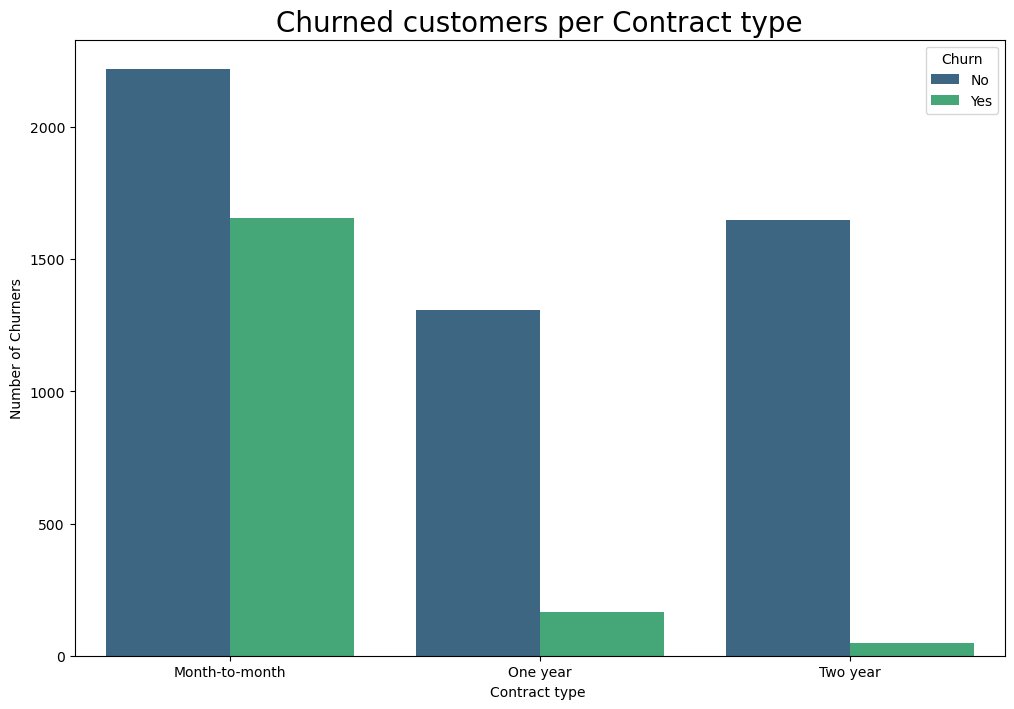

In [21]:
plt.figure(figsize=(12,8))
sns.countplot(data= df, x = "Contract", hue="Churn",
             palette ="viridis")

plt.title("Churned customers per Contract type" , fontsize=20)
plt.ylabel("Number of Churners")
plt.xlabel("Contract type ")
plt.show()

##### From the above chart , the Month to Month subscriber have a relatively high churn behavior than the long contracts customers . 

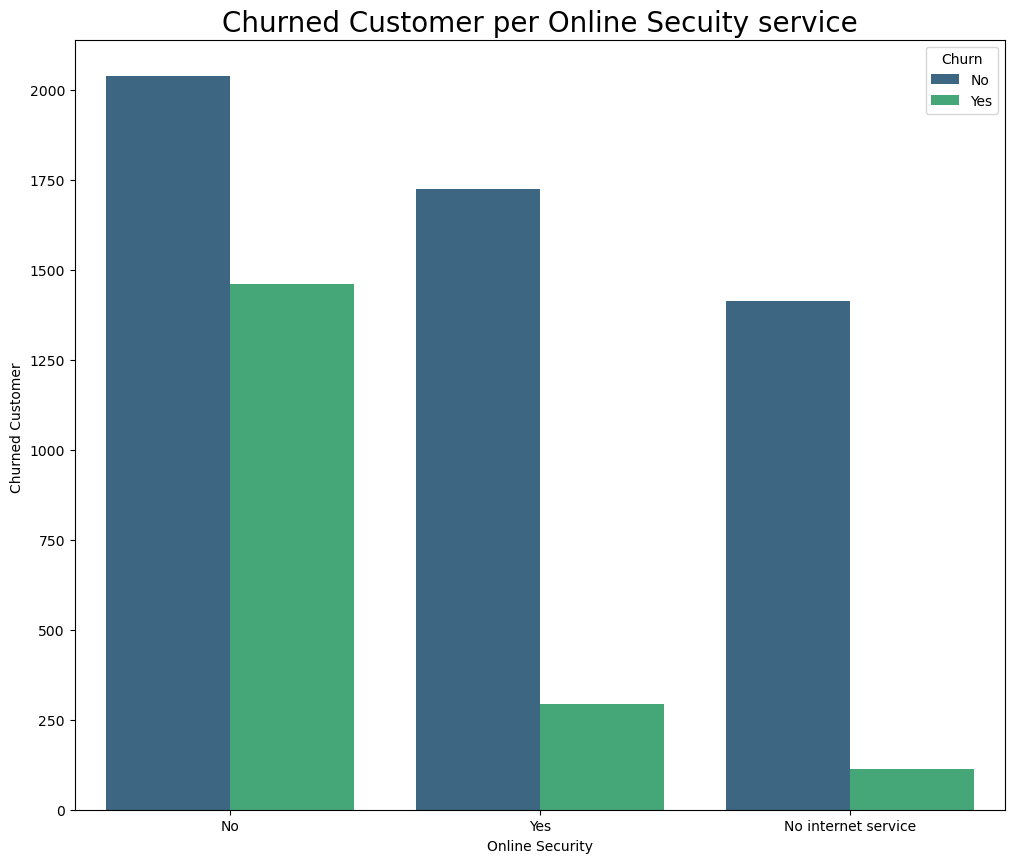

In [22]:
plt.figure(figsize=(12,10))
sns.countplot(data= df , x="OnlineSecurity" , hue ="Churn",
             palette = "viridis")
plt.title("Churned Customer per Online Secuity service" , fontsize=20)
plt.xlabel("Online Security")
plt.ylabel("Churned Customer ")
plt.show()

##### From the above chart , the customers with no online Security have a high churn behavior than the customer with online security service or even the customer with no internet service . 

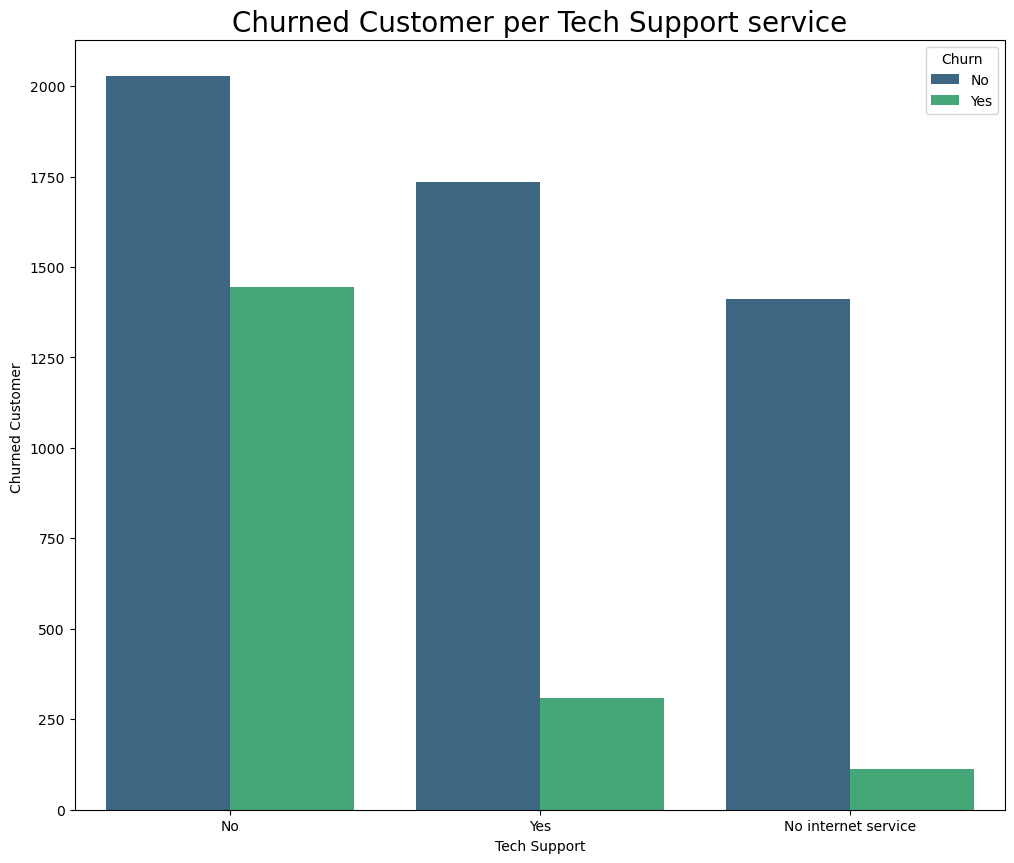

In [23]:
plt.figure(figsize=(12,10))
sns.countplot(data= df , x="TechSupport" , hue ="Churn",
             palette = "viridis")
plt.title("Churned Customer per Tech Support service" , fontsize=20)
plt.xlabel("Tech Support")
plt.ylabel("Churned Customer ")
plt.show()

##### From the above chart , the customers with no Tech Support Service have a high churn behavior than the customer with Tech Support  service or even the customers with no internet service

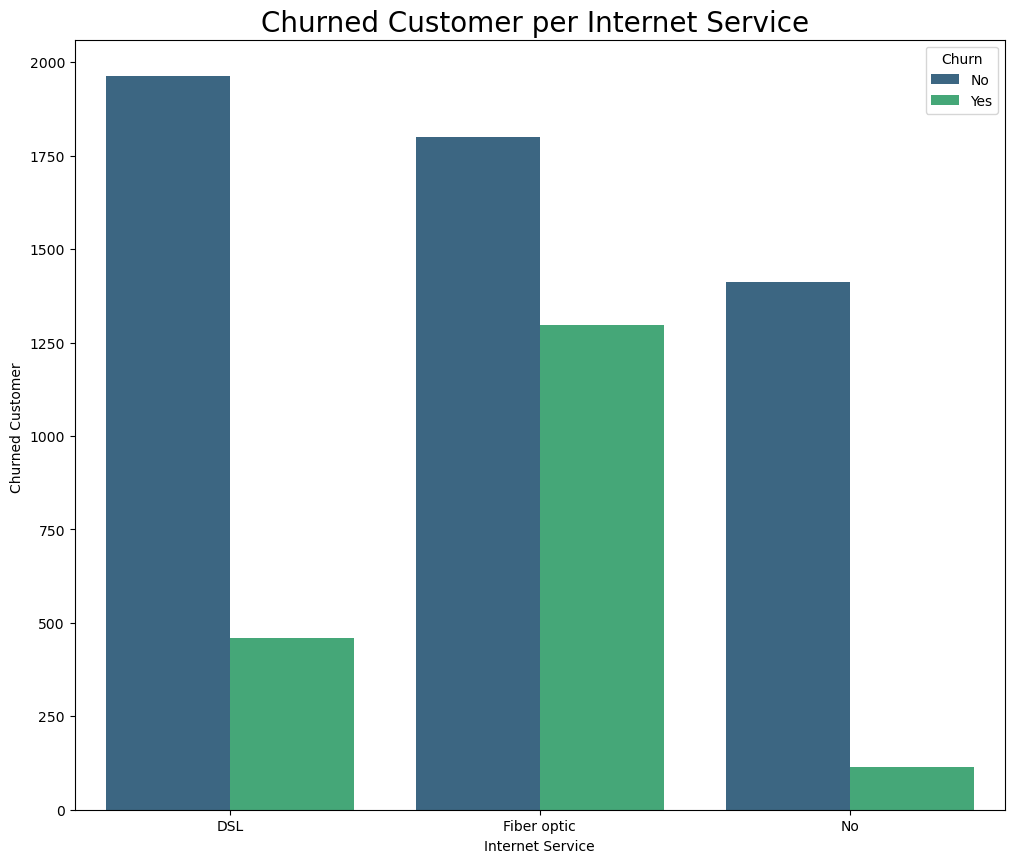

In [24]:
plt.figure(figsize=(12,10))
sns.countplot(data= df , x="InternetService" , hue ="Churn",
             palette = "viridis")
plt.title("Churned Customer per Internet Service " , fontsize=20)
plt.xlabel("Internet Service")
plt.ylabel("Churned Customer ")
plt.show()

##### From the above chart , the customers with FIber optic Internet Service have a high churn behavior than the customer with DSL internet service or even the customers with no internet service . 

In [25]:
num_col = df.select_dtypes(exclude=['object', 'category']).columns
num_col

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')

In [26]:
group1 = df["MonthlyCharges"][df["Churn"] == "Yes"]
group2 = df["MonthlyCharges"][df["Churn"] == "No"]
"""
# MY NULL HYPOTHESIS ; is that the means of the monthly charges 
of people that left and the people that stayed are equal . 
Meanig the monthly charges feature is just noise . 

# MY ALTERNATIVE HYPOTHESIS ;  is that the means of the monthly charges 
of people that left and the people that stayed are different .
Meaning the monthly charges indicates churn behavior 
"""

'\n# MY NULL HYPOTHESIS ; is that the means of the monthly charges \nof people that left and the people that stayed are equal . \nMeanig the monthly charges feature is just noise . \n\n# MY ALTERNATIVE HYPOTHESIS ;  is that the means of the monthly charges \nof people that left and the people that stayed are different .\nMeaning the monthly charges indicates churn behavior \n'

##### Here I calculaed the length of each group and the mean of each group

In [27]:
# group1: Churn = Yes
n1 = len(group1)
mean1 = sum(group1) / n1

# group2: Churn = No
n2 = len(group2)
mean2 = sum(group2) / n2

##### Here is calculated the variance of each group , the spread of the groups 

In [28]:
var1 = sum((x - mean1)**2 for x in group1) / (n1 - 1)
var2 = sum((x - mean2)**2 for x in group2) / (n2 - 1)

In [29]:
# the degree of freedom 
dof = n1+n2 - 2 
dof

7041

#### The Decision Rule 
With a Dof = 7041 and alpha = 0.05 from the t table i find the 
critical value = +-1.96 , this means that it the t_statist value is 
between this range i will accept the null hypothesis . 
Otherwise , i will reject the null Hypothesis .

In [30]:
import math
error = math.sqrt((var1 / n1) + (var2 / n2))

##### Final ,  I calculated the Test Statistics 

In [31]:
t_stat = (mean1 - mean2) / error
t_stat

18.407526676414818

##### From the Test statistics result , I will reject the null hypothesis , because t stat value 18 is significanlty larger than the critical value +- 1.96 ,which means there is a difference between the means of the Monthly Charges of the people that stayed and the people that left  . In summary , the monthly Charges Feature is a strong indicator of Churn behavior . 

####  Below i will do the same process using the libray t test independent 

In [32]:
group1 = df["MonthlyCharges"][df["Churn"] == "Yes"]
group2 = df["MonthlyCharges"][df["Churn"] == "No"]

t_stat , p_value = ttest_ind(group1 , group2)

print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_value:.4f}")

T-Statistic: 16.5367
P-Value: 0.0000


##### Since the P-Value is less than p<0.05 , i will reject the null hypothesis , which means there is a difference between the means of the Monthly Charges of the people that stayed and the people that left . In summary , MonthlyCharges is a strong indicator of churn behavior . 

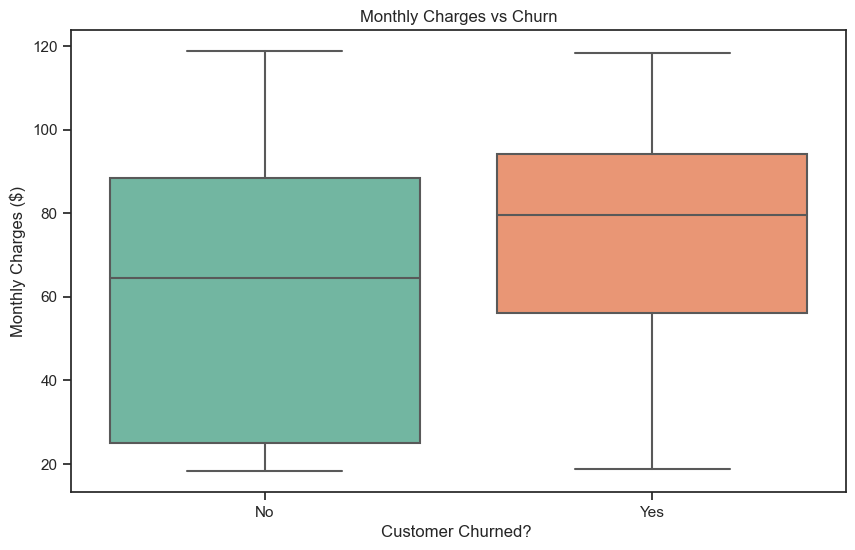

In [33]:
sns.set_theme(style="ticks")
plt.figure(figsize=(10, 6))
sns.boxplot(data = df , x="Churn" , y="MonthlyCharges" ,palette="Set2")
plt.title("Monthly Charges vs Churn")
plt.xlabel("Customer Churned? ")
plt.ylabel("Monthly Charges ($)")
plt.show()

#### Here i did a function find the t_statistic and p value for all the other features . 

In [34]:
def T_stats(column_1) :
    group1 = df[column_1][df["Churn"] == "Yes"]
    group2 = df[column_1][df["Churn"] == "No"]


    t_stat , p_value = ttest_ind(group1 , group2)
    return {
    "t_statistic": t_stat,
    "p_value": p_value }

In [35]:
T_stats("MonthlyCharges")

{'t_statistic': 16.536738015936308, 'p_value': 2.7066456068884154e-60}

In [36]:
dg_col = []
for i in num_col :
    dg_col.append(T_stats(i))

In [37]:
df4 = pd.DataFrame(dg_col, index = num_col)
df4

,t_statistic,p_value
SeniorCitizen,12.807866,3.839860e-37
tenure,-31.579551,7.999058e-205
MonthlyCharges,16.536738,2.706646e-60
TotalCharges,-16.978780,2.127212e-63


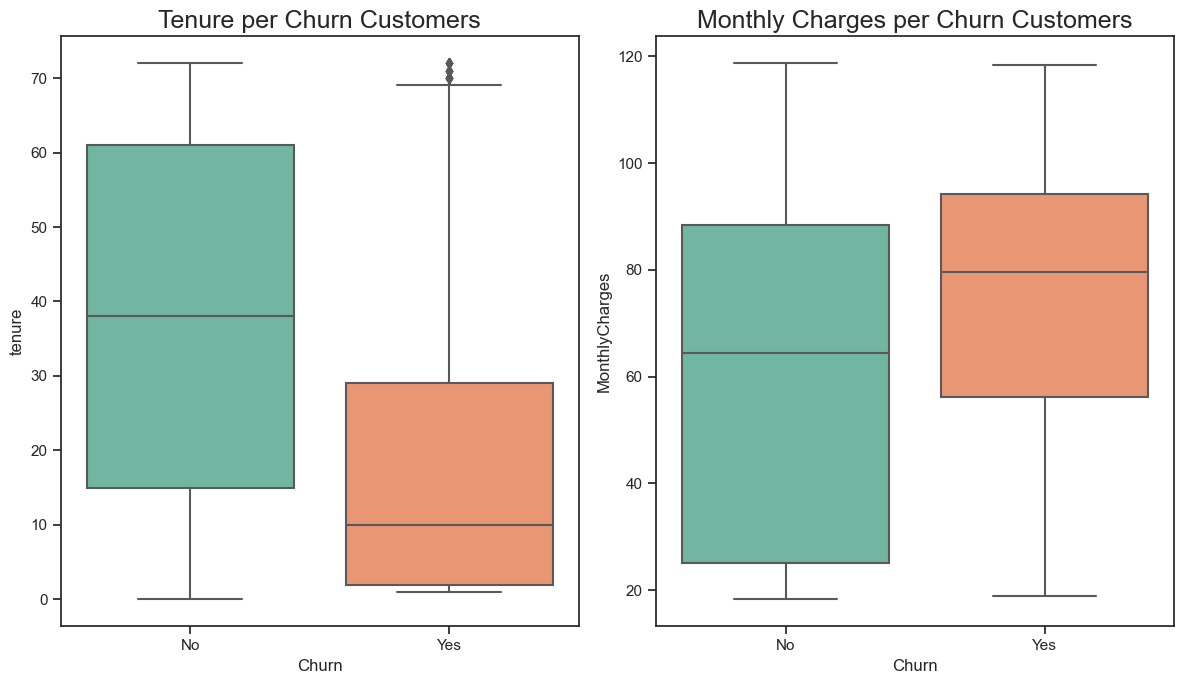

In [38]:
plt.figure(figsize=(12,7))
plt.subplot(1,2, 1)
sns.boxplot(data=df, x="Churn", y="tenure", palette="Set2")
plt.title("Tenure per Churn Customers", fontsize =18)
plt.subplot(1,2, 2)
sns.boxplot(data=df, x="Churn", y="MonthlyCharges", palette="Set2")
plt.title("Monthly Charges per Churn Customers", fontsize = 18)
plt.tight_layout()
plt.show()

#### From the first plot , new customers tend to churn more . 
#### From the second plot , customers with a higher montly charges tend to churn more . 

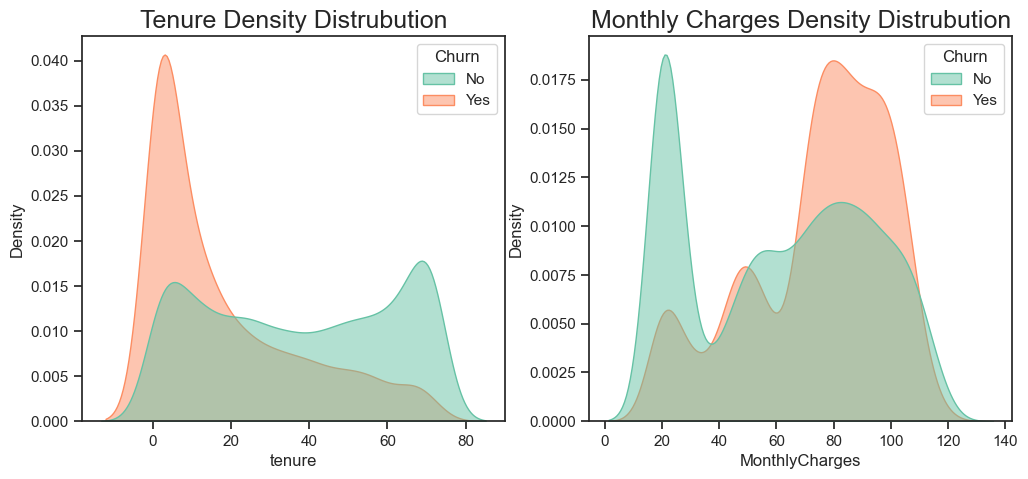

In [39]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.kdeplot(data=df, x="tenure", hue="Churn", fill=True,common_norm=False,  palette="Set2", alpha=0.5)
plt.title("Tenure Density Distrubution", fontsize = 18)
plt.subplot(1,2,2)
sns.kdeplot(data=df, x="MonthlyCharges", hue="Churn", fill=True,common_norm=False,  palette="Set2", alpha=0.5)
plt.title("Monthly Charges Density Distrubution", fontsize = 18)
plt.show()

##### From the first plot , again , the denstiy of the churners seem to be more when the tenure is low , in other words , new customer have a high churn behavior

##### From the second plot , again, the density of churners seem to be more when the Monthly Charges are high , in other words , customers with a high MonthlyCharges have a high churn behavior . 

### The business Reasoning : 

First of all they all have significant indicator of churn behavior 
and [tenure and total charges] features have a negative strong relationships , meaning when 
less tenure(you are a new customer) , u are more likely to churn this also goes with 
the total charges feature because this indicates your historical total bill.
and [monthlycharges ] feature have a positive strong correlations with churn , which means
when u have a higher monthly fee , u are more likely to leave . 

#### I had a very misleading plot on the boxplot of the feature SeniorCitizen and when i look at it more , its not a numerical feature so T-Test is misleading , its a binary Categorical feature and i should run the chi-squared test and cramer V's to evaluate the importance of the feature . Here i changed it data type to boolean .

In [40]:
df['SeniorCitizen'] = df["SeniorCitizen"].astype(bool)
df['SeniorCitizen']

0       False
1       False
2       False
3       False
4       False
        ...  
7038    False
7039    False
7040    False
7041     True
7042    False
Name: SeniorCitizen, Length: 7043, dtype: bool

##### Here i want to find the pvalue of the feature Senior Citizen using the chi - squared test

In [41]:
contingency_table2 = pd.crosstab(df["SeniorCitizen"], df["Churn"])
stats2 , pvalue2 , dof2 , expected2 = chi2_contingency(contingency_table2)
print(stats2) 
print(pvalue2)

159.42630036838742
1.510066805092378e-36


##### The pvalue is less than alpha=0.05 , which means i reject the null hypothesis ,meaning the there is  a  relationship between the feature Senior Citizen and the target Feature Churn . I will run the Cramer V test to see how strong the relationship is .

In [42]:
n2= contingency_table2.sum().sum()
k2= min(contingency_table2.shape)
v2 = np.sqrt(stats2 / (n2 *(k2-1)))
v2

0.15045309974200427

##### After running the cramer V test it looks like the moderate . i think i may keep this feature . because in the categorical features i drop the features with a cramer v value very low . But this value is close .

In [43]:
print("Pvalue ", pvalue2)
print("Cramer v value", v2)

Pvalue  1.510066805092378e-36
Cramer v value 0.15045309974200427


In [44]:
df3 = df3.iloc[1:-3]
df3.loc["SeniorCitizen"] = [ 159.42630036838742 , 5.863038300673391e-258 , 0.15045309974200427 ]
df4 = df4.iloc[1:-1]

# Here i drop the noise columns
df = df.drop(columns = ['MultipleLines' , 'PhoneService', 'gender', "TotalCharges"])


C:\Users\boshe\AppData\Local\Temp\ipykernel_22704\2430796584.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3.loc["SeniorCitizen"] = [ 159.42630036838742 , 5.863038300673391e-258 , 0.15045309974200427 ]


In [45]:
cat_cols2 = df.select_dtypes(include=['object', 'category',"bool"]).columns
cat_cols2 = cat_cols2.drop(["customerID"])

In [46]:
bin_col = []
multi_col = []
for i in df[cat_cols2]:
    if df[i].nunique() == 2  :
        bin_col.append(i)
    else :
        multi_col.append(i)


In [47]:
bin_col

['SeniorCitizen', 'Partner', 'Dependents', 'PaperlessBilling', 'Churn']

In [48]:
multi_col

['InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaymentMethod']

##### Now i should Encode the data , binary columns using Label Encoding and MultiClass Features using OneHotEncoding

In [49]:
df5 = df.copy()
label_encoder = LabelEncoder()
for  i in bin_col :
    df5[i] = label_encoder.fit_transform(df5[i])



df5 = pd.get_dummies(df5, columns=multi_col , drop_first=True)
df5.pop("customerID")
df5

,SeniorCitizen,Partner,Dependents,tenure,PaperlessBilling,MonthlyCharges,Churn,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,0,1,1,29.85,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0
1,0,0,0,34,0,56.95,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1
2,0,0,0,2,1,53.85,1,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1
3,0,0,0,45,0,42.30,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0
4,0,0,0,2,1,70.70,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,1,1,24,1,84.80,0,0,0,0,1,0,0,0,1,0,1,0,1,0,1,1,0,0,0,1
7039,0,1,1,72,1,103.20,0,1,0,0,0,0,1,0,1,0,0,0,1,0,1,1,0,1,0,0
7040,0,1,1,11,1,29.60,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
7041,1,1,0,4,1,74.40,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1


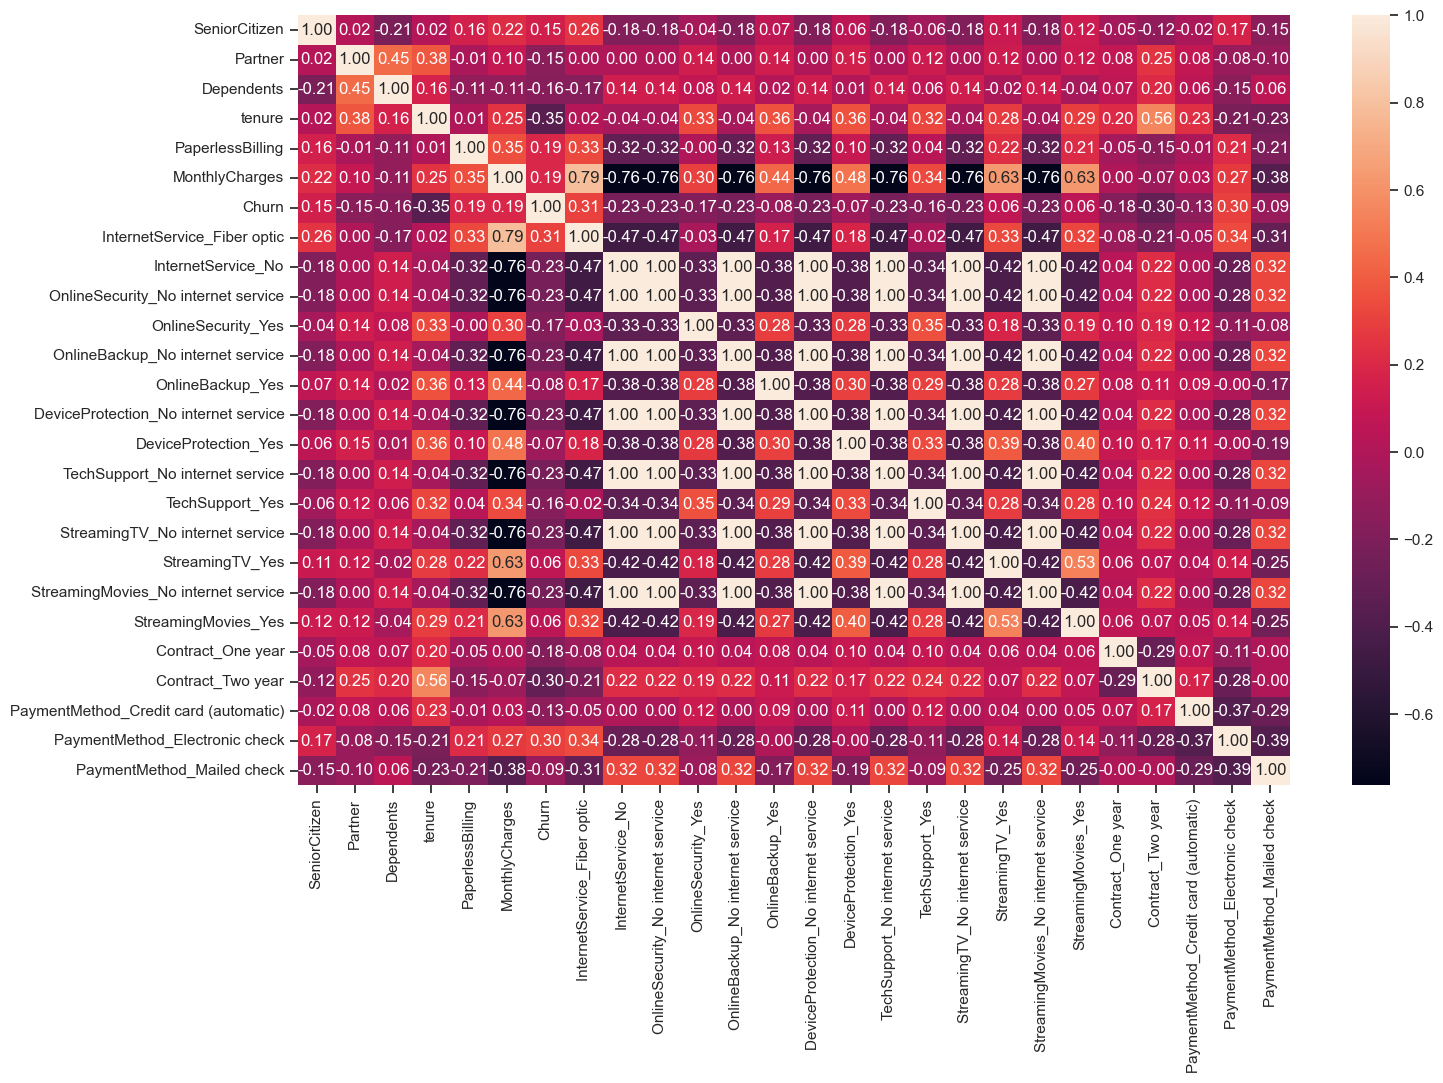

In [50]:
plt.figure(figsize = (16,10))
sns.heatmap(df5.corr(), annot = True , fmt="0.2f" )
plt.show()

In [51]:
df5.corr()["Churn"].abs().sort_values(ascending=False)

Churn                                    1.000000
tenure                                   0.352229
InternetService_Fiber optic              0.308020
Contract_Two year                        0.302253
PaymentMethod_Electronic check           0.301919
DeviceProtection_No internet service     0.227890
StreamingMovies_No internet service      0.227890
TechSupport_No internet service          0.227890
OnlineBackup_No internet service         0.227890
OnlineSecurity_No internet service       0.227890
InternetService_No                       0.227890
StreamingTV_No internet service          0.227890
MonthlyCharges                           0.193356
PaperlessBilling                         0.191825
Contract_One year                        0.177820
OnlineSecurity_Yes                       0.171226
TechSupport_Yes                          0.164674
Dependents                               0.164221
SeniorCitizen                            0.150889
Partner                                  0.150448


In [52]:
df5.corr()["Churn"].abs().sort_values(ascending=False).head(4)[1:].index

Index(['tenure', 'InternetService_Fiber optic', 'Contract_Two year'], dtype='object')

##### After encoding and doing the correlation and the heatmap the features with the most influence on the target variable are the above (NEagative and positive Correlation)

## EDA Summary Report

### 1. Dataset Overview
- Shape : We have 7043 rows and 17 columns
- Data Types : we have 2 numerical features and 15 Categorical features some are binary and some are MultiClass. 
- Missing Values : No missing Values .  
- Target Distribution : The Target feature is highly imbalance , Almost 36 % of customers Churn.


In [53]:
from IPython.display import display, Markdown
display(Markdown(""" ### 2. Feature Analysis
##### The analysis shows the Chi-Squared , P-Values and the Cramer V's of the categorical Features  """))
display(df3) 

display(Markdown(""" ##### The analysis shows the t_test and  P-Values of the Numerical Features """))
display(df4) 

 ### 2. Feature Analysis
##### The analysis shows the Chi-Squared , P-Values and the Cramer V's of the categorical Features  

,stats,Pvalue,Cramer
Contract,1184.596572,5.863038e-258,0.410116
OnlineSecurity,849.998968,2.661150e-185,0.347400
TechSupport,828.197068,1.443084e-180,0.342916
InternetService,732.309590,9.571788e-160,0.322455
PaymentMethod,648.142327,3.682355e-140,0.303359
OnlineBackup,601.812790,2.079759e-131,0.292316
DeviceProtection,558.419369,5.505219e-122,0.281580
StreamingMovies,375.661479,2.667757e-82,0.230951
StreamingTV,374.203943,5.528994e-82,0.230502
PaperlessBilling,258.277649,4.073355e-58,0.191498


 ##### The analysis shows the t_test and  P-Values of the Numerical Features 

,t_statistic,p_value
tenure,-31.579551,7.999058e-205
MonthlyCharges,16.536738,2.706646e-60


### 3. Key Insights
#### A summary of my business findings from visualizations.
- The Month to Month subscriber have a relatively high churn behavior , almost 3 times higher than two - year contract customers contract feature has a (Cramer's V = 0.41) . Meaning its the strongest predictor of churn in our dataset . 
- The customers with FIber optic Internet Service have a high churn behavior, almost 3 times higher than DSL contract customers.They have a correlation value =  0.308020 with churn feature . Meaning the are one of the highest categories that churn . 
- New customers (tenure < 12) tend to have a high churn behavior . almost the average of the churns are within those periods .tenure have a very high negative T- Statistics(-31.57) , meaning its a serious indicator of the churn and most of the churners are new customers . 
- Customers with a higher monthly charges tend to have a high churn behavior . the churners tend to have a higher average monthly charges . Monthly Charges havevery high postive a T-Statistics (16.5) , meaning when monthly charges increase the risk increase significantily . 

- Customers with no additional services tend to have a high churn behavior . Services like (Online Security(Cramer's V = 0.347) , Tech Support(Cramer's V = 0.342) , Internet Services(Cramer's V = 0.322) , Payment Method(Cramer's V = 0.303)) all have a high Cramer's V values . meaning the all influence the prediction of churn in our dataset . 

## 

###  4 . Feature Engineering Decisions
A summary of what I dropped, what I kept and why.
I dropped the features categorical features "MultipleLines" , "PhoneService" , "Gender"  because the have a very very low cramer V's Value which means they have no influence on the target feature , meaning they are just noise. And also from the Numerical feature "Total charges" because its the multiplication of the other features "tenure" and "Monthly Charges" .  Also the Feature  "SeniorCitizen"  at first glimse i looked like a numerical feature but we reclassified it to Binary categorical feature . 
I kept the remaning features because they have a significatn chi- squared tests ( p < 0.01 ) and cramer's V values more than 0.15  . Indicatation strong relationship with the Chrun . 

### 

#####  5. My Recommendations To Business
Based on EDA alone — My recommendatation to my business team even before building a model !

- Customers with Fiber Optic Internet Service tend to have a high churn behavior. They are premium , well informed on the services quality and the prices of the competitors . I recommend on make regular quarterly surveys  asking them about their reviews on the quality of our services and their recommendations on how to improve . This should reduce the Fiber Optic Churn by creating a feedback loop and increasing switching costs to our competitiors and improve there satisfations .
- Month to Month subscibers tend to have a high churn behavior . They are new customers actively comparing market deals and service quality on a 30 - day cycle . I recommend we should make them a offer/ discount if they transition inot long - term contract  that  long term contracts to keep on long periods , until the become loyal customers . by moving them from monthly to annual billing This will reduce the Month to Month churn by making them stable , long term customers .
- Customers with higher monthly charges tend to have a high churn behavior. Conduct a pricing audit to identify customers on suboptimal plans relative to their usage. The sales team should proactively contact high-charge customers with personalized plan recommendations. This reduces churn driven by cost perception while maintaining revenue through right-sizing rather than blanket discounts.
- New customers (tenure < 12) tend to have a high churn behavior. They are new customers that are still accessing our services and searching for the best services and prices . I recommend we make free premium Features like Online Security and Tech Support for the first 6 month . From my analysis these specific services have a strong relationship with churn . This will increase the switching the switching cost help them settle in . significantly reducing early churn and making them loyal customers. 
- Customers with no additional services like Online Security and TechSupport tend to have a high churn behavior . They are customers that are not informed about our additional services . I recommend we need to introduce them to our new services that they might find useful . This should make them more attached to us , making there switching costs higher . 

## 4. Data preprocessing

In [54]:
X = df5.drop(columns=["Churn"])
Y = df5["Churn"]

In [55]:
xtrain, xtest, ytrain , ytest = train_test_split(X,Y, random_state=42,test_size=0.2,
                                                 stratify=Y)

##### After spliting the dataset into train and test split . now i should perform the scaling for the training data

In [56]:
scaler = RobustScaler()
xtrain[["tenure", "MonthlyCharges"]] = scaler.fit_transform(xtrain[["tenure", "MonthlyCharges"]])
xtest[["tenure", "MonthlyCharges"]] = scaler.transform(xtest[["tenure", "MonthlyCharges"]])

##### Here i should work on handling the class imbalance , 2 approaches  . first one is the SMOTE approach and the second one is the Class Weight .  

## 5.Modeling

#### First approach SMOTE

In [57]:
from imblearn.over_sampling import SMOTE 
sm = SMOTE(random_state=42)
xtrain_res , ytrain_res = sm.fit_resample(xtrain,ytrain) 

#### Logistic Regression using SMOTE 

In [58]:
model_lgr = LogisticRegression( random_state=42 )
model_lgr.fit(xtrain_res , ytrain_res)
ypred_lgr = model_lgr.predict(xtest)

In [59]:
conf_matrix = confusion_matrix(ytest , ypred_lgr)
conf_matrix


array([[750, 285],
       [ 90, 284]], dtype=int64)

#### almost the 284 / 374 churns have been detected which is good , very good recall
#### however more than 280 non churns have been labeled churn , very bad precision

In [61]:
print(classification_report(ytest , ypred_lgr , target_names=["Non Churn","Churn"] ) )

              precision    recall  f1-score   support

   Non Churn       0.89      0.72      0.80      1035
       Churn       0.50      0.76      0.60       374

    accuracy                           0.73      1409
   macro avg       0.70      0.74      0.70      1409
weighted avg       0.79      0.73      0.75      1409



In [62]:
lgr_sm_f2 = fbeta_score(ytest, ypred_lgr, beta=2)
print(f"F2-Score: {lgr_sm_f2:.4f}")


F2-Score: 0.6877


In [63]:
y_probs_lgr_sm = model_lgr.predict_proba(xtest)[:, 1]

auc_score = roc_auc_score(ytest, y_probs_lgr_sm)
print(f"Logistic Regression(SMOTE) AUC: {auc_score:.4f}")



Logistic Regression(SMOTE) AUC: 0.8279


"\nfpr, tpr, thresholds = roc_curve(ytest, y_probs_lgr_sm)\nplt.figure(figsize=(6, 4))\nplt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc_score:.2f})')\nplt.plot([0, 1], [0, 1], 'k--') \nplt.xlabel('False Positive Rate')\nplt.ylabel('True Positive Rate')\nplt.title('ROC Curve')\nplt.legend()\nplt.show() "

#### Random Forest Using SMOTE 

In [64]:
model_rf = RandomForestClassifier(random_state=42)
model_rf.fit(xtrain_res , ytrain_res)
ypred_rf = model_rf.predict(xtest)

In [65]:
conf_matrix_rf = confusion_matrix(ytest , ypred_rf)
conf_matrix_rf

array([[836, 199],
       [140, 234]], dtype=int64)

In [66]:
print(classification_report(ytest , ypred_rf, target_names=["Non Churn","Churn"]) ) 

              precision    recall  f1-score   support

   Non Churn       0.86      0.81      0.83      1035
       Churn       0.54      0.63      0.58       374

    accuracy                           0.76      1409
   macro avg       0.70      0.72      0.71      1409
weighted avg       0.77      0.76      0.76      1409



In [67]:
rf_sm_f2 = fbeta_score(ytest, ypred_rf, beta=2)
print(f"F2-Score: {rf_sm_f2:.4f}")



F2-Score: 0.6065


In [68]:
y_probs_rf_sm = model_rf.predict_proba(xtest)[:, 1]

auc_score = roc_auc_score(ytest, y_probs_rf_sm)
print(f"Random Forest(SMOTE) AUC: {auc_score:.4f}")


Random Forest(SMOTE) AUC: 0.8117


#### XGBoost Classifier Using SMOTE

In [108]:
model_xgb_sm = XGBClassifier(n_estimators = 100 , learning_rate=0.05 , n_jobs=4 
                          , random_state = 42, max_depth=6 )

model_xgb_sm.fit(xtrain_res,ytrain_res)
ypred_xgb_sm = model_xgb_sm.predict(xtest)

In [109]:
conf_matrix_xgb_sm = confusion_matrix(ytest , ypred_xgb_sm)
conf_matrix_xgb_sm

array([[768, 267],
       [ 88, 286]], dtype=int64)

In [71]:
print(classification_report(ytest , ypred_xgb_sm, target_names=["Non Churn","Churn"]) ) 

              precision    recall  f1-score   support

   Non Churn       0.90      0.74      0.81      1035
       Churn       0.52      0.76      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.80      0.75      0.76      1409



In [72]:
xgb_sm_f2 = fbeta_score(ytest, ypred_xgb_sm, beta=2)
print(f"F2-Score: {xgb_sm_f2:.4f}")


F2-Score: 0.6979


In [73]:
y_probs_xgb_sm = model_xgb_sm.predict_proba(xtest)[:, 1]

auc_score = roc_auc_score(ytest, y_probs_xgb_sm)
print(f"XGBoost(SMOTE) AUC: {auc_score:.4f}")

XGBoost(SMOTE) AUC: 0.8349


# 

### Second approach called "Class Weight"

# 

#### Logistic Regression Using Class Weight "Balanced"

Text(47.24999999999999, 0.5, 'Actual label')

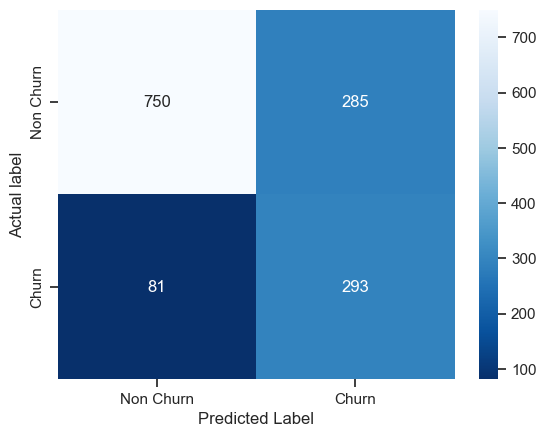

In [74]:
model_lgr_cw = LogisticRegression( random_state=42, class_weight = "balanced")
model_lgr_cw.fit(xtrain, ytrain)
ypred_lgr_cw = model_lgr_cw.predict(xtest)

conf_matrix_lgr_cw = confusion_matrix(ytest , ypred_lgr_cw)
sns.heatmap(conf_matrix_lgr_cw, annot=True , fmt='d', cmap="Blues_r" , 
           xticklabels = ["Non Churn", "Churn"] ,
           yticklabels = ["Non Churn" , "Churn"])


plt.xlabel("Predicted Label")
plt.ylabel("Actual label")

In [75]:
print(classification_report(ytest , ypred_lgr_cw, target_names=["Non Churn","Churn"]) ) 

              precision    recall  f1-score   support

   Non Churn       0.90      0.72      0.80      1035
       Churn       0.51      0.78      0.62       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



In [76]:
lgr_cw_f2 = fbeta_score(ytest, ypred_lgr_cw, beta=2)
print(f"F2-Score: {lgr_cw_f2:.4f}")

F2-Score: 0.7064


In [110]:
y_probs_lgr_cw = model_lgr_cw.predict_proba(xtest)[:, 1]

auc_score = roc_auc_score(ytest, y_probs_lgr_cw)
print(f"Logistic Regression (CW) AUC: {auc_score:.4f}")

Logistic Regression (CW) AUC: 0.8377


#### Below I will do Hyperparameter tuning in my best model , I will do a GridSearchCV to see the best hyperparameters values , that give me the best roc_auc values . I specifically choose roc_auc , because its threshold independent and it finds the best model regardless of cutoff . 

In [78]:
param_grid = {
    
    "C" : [0.01 , 0.1, 1,10,100 ] ,
    "penalty" : ['l1','l2'] ,
    "solver" : ["liblinear" , "saga"] 
} 

clf = GridSearchCV(estimator = LogisticRegression(random_state = 42) ,
                   param_grid = param_grid,
                   cv = 5 , 
                   scoring="roc_auc" )

In [79]:
clf.fit(xtrain, ytrain)
clf.cv_results_ 
df_clf = pd.DataFrame(clf.cv_results_ )
pd.set_option('display.max_colwidth', None)
df_clf[["params" , "mean_test_score" ]].sort_values(by="mean_test_score" , ascending= False).head(3)

,params,mean_test_score
11,"{'C': 1, 'penalty': 'l2', 'solver': 'saga'}",0.843155
9,"{'C': 1, 'penalty': 'l1', 'solver': 'saga'}",0.843122
10,"{'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}",0.843120


#### Here after fitting my model it looks like the best results are with the hyperparameters values [ C = 1 ,  penalty = l2(Ridge)  , solver = "saga" ] and the mean_test_score  = 0.843155 .
#### There is a slight imporvement of  my roc_auc value  .

Average Precision: 0.6303


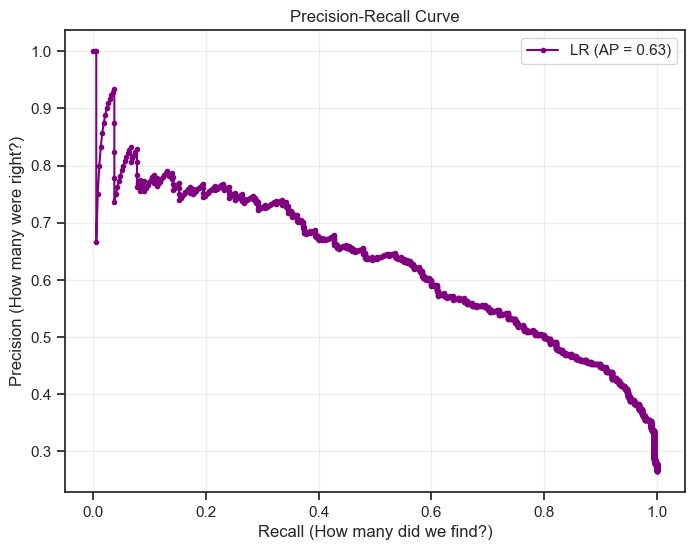

In [111]:
y_probs_lgr = model_lgr_cw.predict_proba(xtest)[:, 1]
precision, recall, thresholds = precision_recall_curve(ytest, y_probs_lgr)

ap_score = average_precision_score(ytest, y_probs_lgr)
print(f"Average Precision: {ap_score:.4f}")

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, marker='.', label=f'LR (AP = {ap_score:.2f})', color='purple')
plt.xlabel('Recall (How many did we find?)')
plt.ylabel('Precision (How many were right?)')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

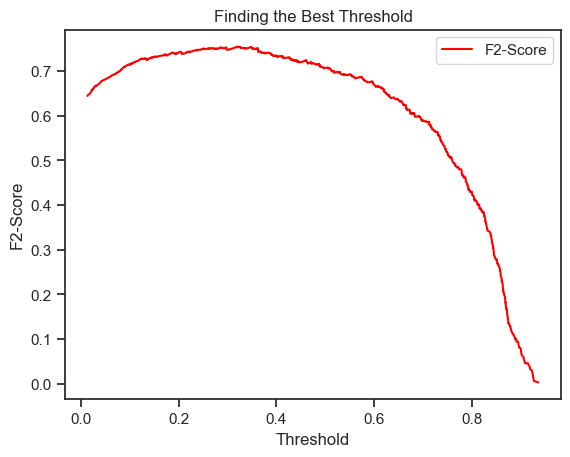

Best Threshold: 0.32
Best F2-Score: 0.7544


In [81]:
y_probs = model_lgr_cw.predict_proba(xtest)[:, 1]
prec, rec, thresholds = precision_recall_curve(ytest, y_probs)

# F2 = (5 * precision * recall) / (4 * precision + recall)
f2_scores = (5 * prec * rec) / (4 * prec + rec + 1e-10)
plt.plot(thresholds, f2_scores[:-1], color='red', label='F2-Score')
plt.title('Finding the Best Threshold')
plt.xlabel('Threshold')
plt.ylabel('F2-Score')
plt.legend()
plt.show()
best_idx = np.argmax(f2_scores)
print(f"Best Threshold: {thresholds[best_idx]:.2f}")
print(f"Best F2-Score: {f2_scores[best_idx]:.4f}")

#### Below i will modify the threshold of the make to the threshold of the best F2- Score which is 0.32 to get the best results 

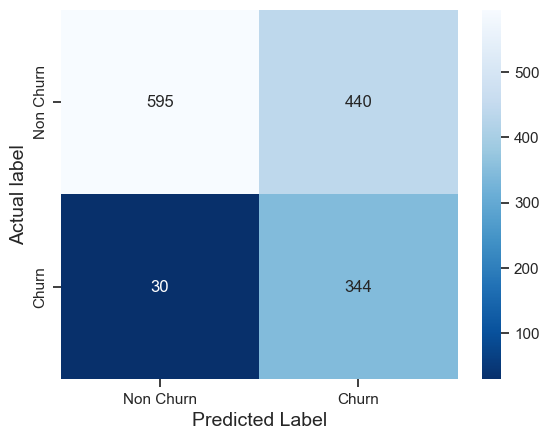

In [120]:
optimal_threshold = thresholds[best_idx]
lgr_pred_final = (y_probs_lgr >= optimal_threshold).astype(int)
lgr_final_con_matrix = confusion_matrix(ytest , lgr_pred_final)

sns.heatmap(lgr_final_con_matrix, annot=True , fmt='d', cmap="Blues_r" , 
           xticklabels = ["Non Churn", "Churn"] ,
           yticklabels = ["Non Churn" , "Churn"])

plt.xlabel("Predicted Label", fontsize=14)
plt.ylabel("Actual label", fontsize=14)

plt.show()

In [115]:
print(classification_report(ytest,  lgr_pred_final))

              precision    recall  f1-score   support

           0       0.95      0.57      0.72      1035
           1       0.44      0.92      0.59       374

    accuracy                           0.67      1409
   macro avg       0.70      0.75      0.66      1409
weighted avg       0.82      0.67      0.68      1409



In [116]:
auc2 = roc_auc_score(ytest, y_probs_lgr)
print(f"ROC AUC:   {auc2:.4f}")

ROC AUC:   0.8377


#### After changing the threshold , the recall increase and the precision decreasced . Which means we caught more churners and aslo have more false alarms . But business wise , we can deal with this .

#### Random Forest using Class Weight "Balanced"

Text(47.24999999999999, 0.5, 'Actual label')

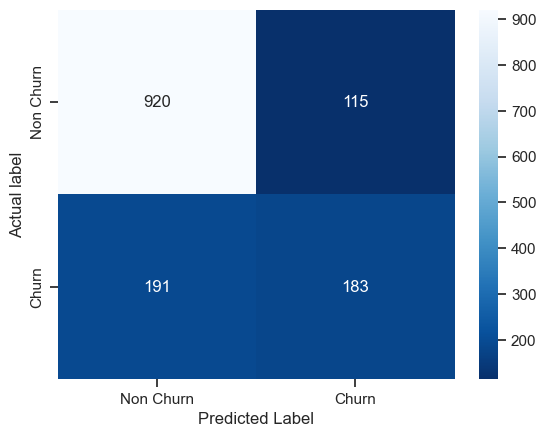

In [86]:
model_rf_cw = RandomForestClassifier(random_state=42 , class_weight = "balanced" )
model_rf_cw.fit(xtrain,  ytrain)
ypred_rf_cw = model_rf_cw.predict(xtest)


conf_matrix_rf_cw = confusion_matrix(ytest , ypred_rf_cw)
sns.heatmap(conf_matrix_rf_cw, annot=True , fmt='d', cmap="Blues_r" , 
           xticklabels = ["Non Churn", "Churn"] ,
           yticklabels = ["Non Churn" , "Churn"])


plt.xlabel("Predicted Label")
plt.ylabel("Actual label")

In [87]:
print(classification_report(ytest , ypred_rf_cw, target_names=["Non Churn","Churn"]) ) 

              precision    recall  f1-score   support

   Non Churn       0.83      0.89      0.86      1035
       Churn       0.61      0.49      0.54       374

    accuracy                           0.78      1409
   macro avg       0.72      0.69      0.70      1409
weighted avg       0.77      0.78      0.77      1409



In [88]:
rf_cw_f2 = fbeta_score(ytest, ypred_rf_cw, beta=2)
print(f"F2-Score: {rf_cw_f2:.4f}")

F2-Score: 0.5100


In [89]:
y_probs_rf_cw = model_rf_cw.predict_proba(xtest)[:, 1]

auc_score = roc_auc_score(ytest, y_probs_rf_cw)
print(f"Random Forest AUC: {auc_score:.4f}")

Random Forest AUC: 0.8227


#### XGBoost Classifier using Class Weight "Balanced"

In [90]:
ratio = float(df['Churn'].value_counts()[0] / df['Churn'].value_counts()[1])

model_xgb_cw = XGBClassifier( n_estimators=100, learning_rate=0.05, n_jobs=4, random_state=42,
                             max_depth=6, scale_pos_weight=ratio )

model_xgb_cw.fit(xtrain,ytrain)
ypred_xgb_cw = model_xgb_cw.predict(xtest)

C:\Users\boshe\anaconda3\lib\site-packages\xgboost\core.py:160: UserWarning: [23:43:00] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0b3782d1791676daf-1\xgboost\xgboost-ci-windows\src\learner.cc:742: 
Parameters: { "class_weight", "n_estimatiors" } are not used.

  warnings.warn(smsg, UserWarning)


In [91]:
conf_matrix_xgb_cw = confusion_matrix(ytest , ypred_xgb_cw)
conf_matrix_xgb_cw

array([[918, 117],
       [175, 199]], dtype=int64)

In [92]:
print(classification_report(ytest , ypred_xgb_cw, target_names=["Non Churn","Churn"]) ) 
xgb_cw_f2 = fbeta_score(ytest, ypred_xgb_cw, beta=2)
print(f"F2-Score: {xgb_cw_f2:.4f}")

              precision    recall  f1-score   support

   Non Churn       0.84      0.89      0.86      1035
       Churn       0.63      0.53      0.58       374

    accuracy                           0.79      1409
   macro avg       0.73      0.71      0.72      1409
weighted avg       0.78      0.79      0.79      1409

F2-Score: 0.5491


In [93]:
y_probs_xgb_cw = model_xgb_cw.predict_proba(xtest)[:, 1]

auc_score = roc_auc_score(ytest, y_probs_xgb_cw)
print(f"XGBoost AUC: {auc_score:.4f}")

XGBoost AUC: 0.8417


## 6. Model Evaluation

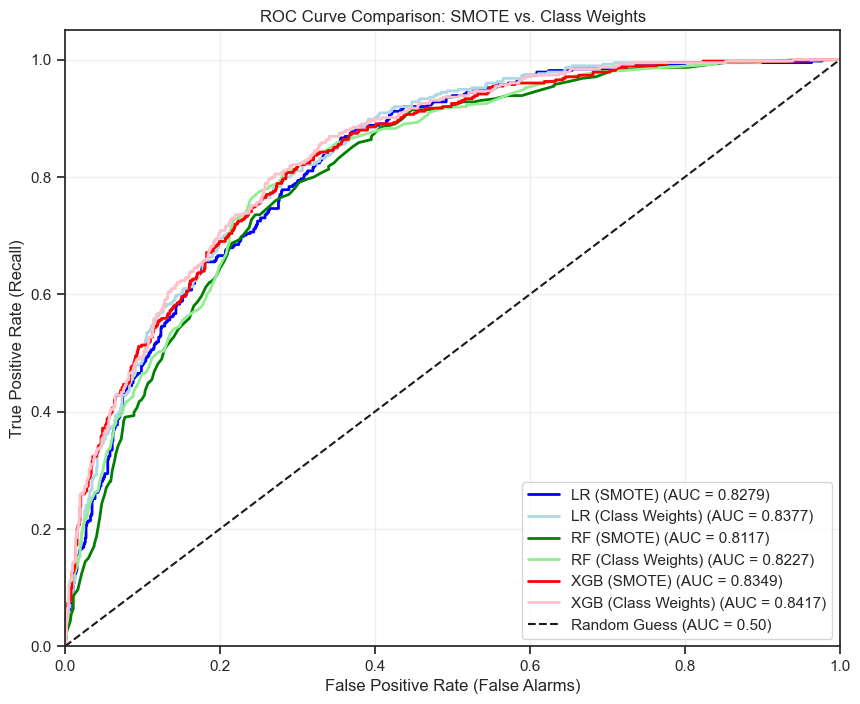

In [94]:

models = [
    (model_lgr, "LR (SMOTE)", "blue"),
    (model_lgr_cw,    "LR (Class Weights)", "lightblue"),
    (model_rf,  "RF (SMOTE)", "green"),
    (model_rf_cw,     "RF (Class Weights)", "lightgreen"),
    (model_xgb_sm, "XGB (SMOTE)", "red"),
    (model_xgb_cw,    "XGB (Class Weights)", "pink")
]


plt.figure(figsize=(10, 8))

for model, label, color in models:
    probs = model.predict_proba(xtest)[:, 1]
    
    
    fpr, tpr, _ = roc_curve(ytest, probs)
    auc = roc_auc_score(ytest, probs)
    plt.plot(fpr, tpr, label=f'{label} (AUC = {auc:.4f})', color=color, lw=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.50)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (False Alarms)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve Comparison: SMOTE vs. Class Weights')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

## 7. Feature Engineering 

##### Below i will do feature engineering , adding 3 new values 
- "LoyalyRatio" which is tenure divided by MonthlyCharges
- "ServiceCount" which is the sum of the 6 added services [ 'OnlineSecurity' , 'OnlineBackup' , 'DeviceProtection' , 'TechSupport' , 'StreamingTV' , 'StreamingMovies' ]
- "IsNewCustomer" which is the indciator if this person had less than 6 month labeled new customer given value 1 or someone with more ,old customers given value 0

#### so I will make a new copy of the dataset , add those values , split the data ,make the train-test-split , do the scaling , make change the threshold and retrain the model . see the values of ROC-AUC , recall , precision , and F2-score if they decreased or increased . 

In [95]:
df6 = df.copy()
added_services = [ 'OnlineSecurity' , 'OnlineBackup' , 'DeviceProtection' , 'TechSupport' , 'StreamingTV' , 'StreamingMovies' ]
df6['LoyaltyRatio'] = df6['tenure'] / df6['MonthlyCharges']
df6['ServiceCount'] = (df6[added_services] == "Yes").sum(axis=1)
df6['IsNewCustomer'] = np.where(df6['tenure'] < 6, 1, 0) 

In [96]:
df7 = df6.copy()
label_encoder = LabelEncoder()
for  i in bin_col :
    df7[i] = label_encoder.fit_transform(df7[i])



df7 = pd.get_dummies(df7, columns=multi_col , drop_first=True)
df7.pop("customerID")


0       7590-VHVEG
1       5575-GNVDE
2       3668-QPYBK
3       7795-CFOCW
4       9237-HQITU
           ...    
7038    6840-RESVB
7039    2234-XADUH
7040    4801-JZAZL
7041    8361-LTMKD
7042    3186-AJIEK
Name: customerID, Length: 7043, dtype: object

In [97]:
x2 = df7.drop(columns=["Churn"])
y2 = df7["Churn"]

In [98]:
xtrain2, xtest2, ytrain2, ytest2 =  train_test_split(x2, y2, test_size=0.2 , stratify = y2, random_state=42)

In [99]:
scaler2 = RobustScaler()
xtrain2[["tenure", "MonthlyCharges","LoyaltyRatio" , "ServiceCount"]] = scaler2.fit_transform(xtrain2[["tenure", "MonthlyCharges","LoyaltyRatio" , "ServiceCount"]])
xtest2[["tenure", "MonthlyCharges","LoyaltyRatio" , "ServiceCount"]] = scaler2.transform(xtest2[["tenure", "MonthlyCharges","LoyaltyRatio" , "ServiceCount"]])

## 8 . Final Model & Results

In [100]:
model_lgr_cw2 = LogisticRegression(random_state=42 , class_weight = "balanced")
model_lgr_cw2.fit(xtrain2, ytrain2)
ypred_lgr_cw2 = model_lgr_cw2.predict(xtest2)
y_probs_lgr2 = model_lgr_cw2.predict_proba(xtest2)[:, 1]


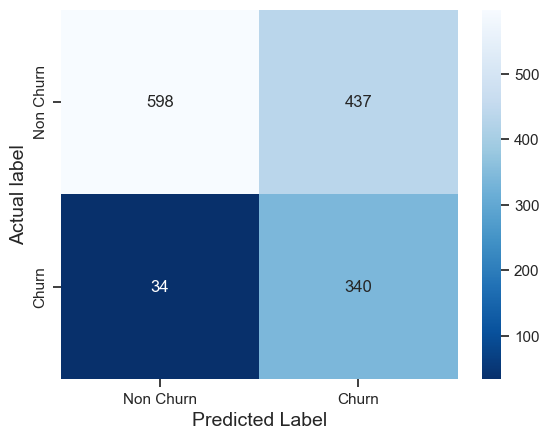

In [101]:
lgr_pred_final2 = (y_probs_lgr2 >= 0.32).astype(int)
lgr_final_con_matrix2 = confusion_matrix(ytest2 , lgr_pred_final2)
sns.heatmap(lgr_final_con_matrix2, annot=True , fmt='d', cmap="Blues_r" , 
           xticklabels = ["Non Churn", "Churn"] ,
           yticklabels = ["Non Churn" , "Churn"])

plt.xlabel("Predicted Label", fontsize=14)
plt.ylabel("Actual label", fontsize=14)

plt.show()

In [102]:
rec = recall_score(ytest2, lgr_pred_final2)
prec = precision_score(ytest2, lgr_pred_final2)
f2 = fbeta_score(ytest2, lgr_pred_final2, beta=2)

auc = roc_auc_score(ytest2, y_probs_lgr2)

In [103]:
print(classification_report(ytest2 , lgr_pred_final2, target_names=["Non Churn","Churn"]) ) 

              precision    recall  f1-score   support

   Non Churn       0.95      0.58      0.72      1035
       Churn       0.44      0.91      0.59       374

    accuracy                           0.67      1409
   macro avg       0.69      0.74      0.65      1409
weighted avg       0.81      0.67      0.68      1409



In [104]:
print(f"Recall:    {rec:.4f}")
print(f"Precision: {prec:.4f}")
print(f"F2-Score:  {f2:.4f}")
print(f"ROC AUC:   {auc:.4f}")


Recall:    0.9091
Precision: 0.4376
F2-Score:  0.7479
ROC AUC:   0.8462


### Feature Engineering produced small improvement — ROC-AUC and  F2 slightly improved . WE can retain the new features in the final model . 

### Feature Importance

### Here i will choose to find the feature importance using mutual_information 

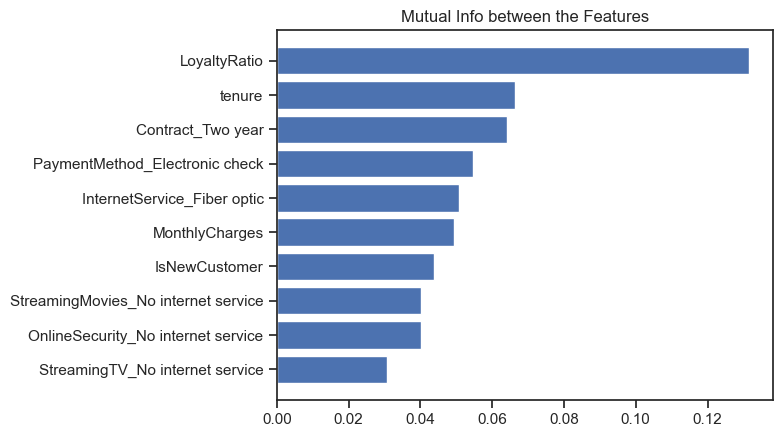

In [105]:
mi_score = mutual_info_classif(xtrain2 , ytrain2 , random_state=42)
mi_results = pd.Series(mi_score, index= xtrain2.columns)
mi_results = mi_results.sort_values(ascending=False).head(10)

plt.barh(range(len(mi_results)) , mi_results.values)
plt.yticks( range(len(mi_results)) , mi_results.index)
plt.gca().invert_yaxis()
plt.title("Mutual Info between the Features")
plt.show()


### Final comment about the Feature Importance 



- if loyaltyratio increases it decreases churn probability because more loyalty score means u will not churn , 
- if tenure increase it decrese churn probability u have been with us long enough u dont want to churn  , 
- if its contract_two_year it decrease churn probabilty i have a long contract u wont leave us any time soon ,
- if its paymentmethod_electronic check it increase churn probabiilty because the customer think twice and may feel the burden - if its internet fiber optic it increase churn probabilty because u are more market aware and continiously looking for better service and prices  

####  speaking about loyalty ratio,it turned out more predictive than the original because tenure alone doesnot tell u about the burden of the monthly charges and the monthly charges alone doesnot tell me it the customer is loyal or new customer . thats why this feature makes a good balance. 

Logistic Regression AUC: 0.8462


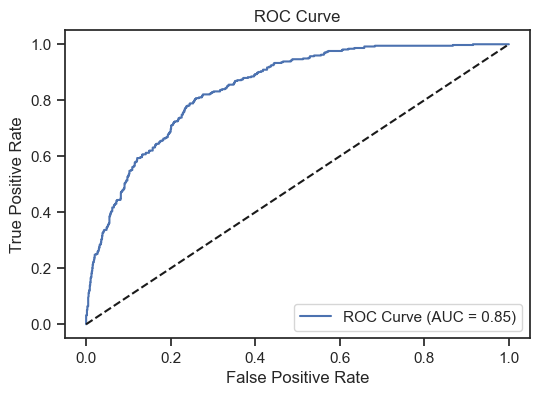

In [107]:
auc_score = roc_auc_score(ytest2, y_probs_lgr2)
print(f"Logistic Regression AUC: {auc_score:.4f}")

fpr, tpr, thresholds = roc_curve(ytest2, y_probs_lgr2)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], 'k--') 
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

### FINAL MODEL SUMMARY
====================
- Model:     Logistic Regression + Class Weights
- Threshold: 0.32
- Features:  Original + 3 Engineered Features

### FINAL RESULTS
=============
- ROC-AUC:   0.846
- Recall:    0.909
- Precision: 0.438
- F2-Score:  0.748

## 9. Conclusion

### What We Built
We built an end-to-end binary classification pipeline to predict customer churn for a telecom company. The final model is a Logistic Regression with a Class Weights approach, optimized at a custom decision threshold of 0.32. By prioritizing the cost of "false negatives" (undetected churners), we moved away from the default 0.5 threshold to ensure maximum business impact.

### Key Findings
- Contract Type is the strongest predictor of churn (Cramér's V = 0.41)
- Fiber Optic customers churn despite using the premium service
- Customers with tenure < 6 months represent the highest risk segment
- LoyaltyRatio engineered feature outperformed all original features
- The optimal decision threshold was 0.32 instead of the default 0.5

### Final Model Performance
| Metric | Value |
|---|---|
| ROC-AUC | 0.846 |
| Recall | 0.91 |
| Precision | 0.438 |
| F2-Score | 0.75 |


### Business Impact
Out of 374 real churners in the test set — our model 
successfully identified 340 before they left. Only 34
churners went undetected.

### Limitations
- The dataset is from specific Kaggle dataset and may not reflect current market conditions
- The model was trained on a single telecom company's data — 
  generalization to other companies is not guaranteed
- Precision of 0.438 means roughly half of retention calls 
  are spent on customers who weren't going to leave anyway

### Future Work
- Test ensemble stacking approaches: Combining the stability of Logistic Regression with the power of XGBoost.
- Continuous Learning: Collect more recent data and retrain periodically
- Deep Learning: Explore deep learning with larger dataset